# Random Forest

## Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

## Load Titanic Dataset

In [17]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Select Important Columns

In [18]:
df =df[["pclass", "sex", "age", "fare", "survived"]]
df.head()

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


## Handle Missing Data

In [19]:
df= df.dropna()
df

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0
...,...,...,...,...,...
885,3,female,39.0,29.1250,0
886,2,male,27.0,13.0000,0
887,1,female,19.0,30.0000,1
889,1,male,26.0,30.0000,1


## Convert Categorical -> Numerical

In [20]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0
...,...,...,...,...,...
885,3,1,39.0,29.1250,0
886,2,0,27.0,13.0000,0
887,1,1,19.0,30.0000,1
889,1,0,26.0,30.0000,1


## Seperate Features and Traget

In [22]:
X= df[["pclass", "sex", "age", "fare"]]
y= df["survived"]
X, y

(     pclass  sex   age     fare
 0         3    0  22.0   7.2500
 1         1    1  38.0  71.2833
 2         3    1  26.0   7.9250
 3         1    1  35.0  53.1000
 4         3    0  35.0   8.0500
 ..      ...  ...   ...      ...
 885       3    1  39.0  29.1250
 886       2    0  27.0  13.0000
 887       1    1  19.0  30.0000
 889       1    0  26.0  30.0000
 890       3    0  32.0   7.7500
 
 [714 rows x 4 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 885    0
 886    0
 887    1
 889    1
 890    0
 Name: survived, Length: 714, dtype: int64)

## Train_Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Build Random Forest Model

In [26]:
model =RandomForestClassifier(n_estimators=200, 
                                   max_depth= 8,
                                   random_state= 42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

## Pridict and Evaluate

In [28]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.7902097902097902
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        87
           1       0.74      0.71      0.73        56

    accuracy                           0.79       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.79      0.79      0.79       143



## Feature Importance

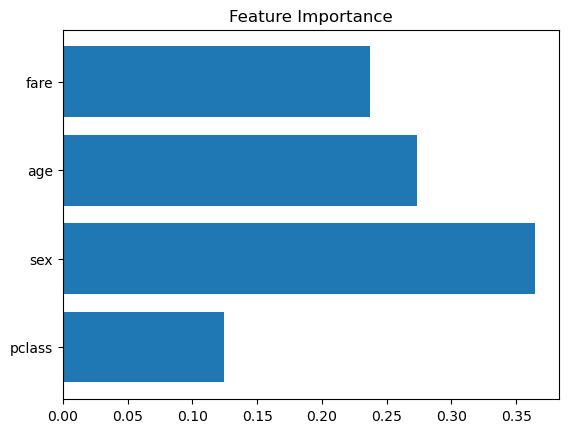

In [30]:
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

## Predict for New passenger

In [35]:
input_data = pd.DataFrame([[3, 1, 30, 50]],
                          columns=["pclass", "sex", "age", "fare"])
model.predict(input_data)


array([0])